# 📦 ***Library & Setup***

## 🔧***Library***

In [ ]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import random
import seaborn as sns
import os
from google.colab import drive
from collections import Counter

## 🔌***Mount & Load Dataset***

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/IDSC 2026/Dataset/Labels.csv")

if "Unnamed: 4" in dataset.columns:
    dataset = dataset.drop(columns=["Unnamed: 4"])

folder_gambar = "/content/drive/MyDrive/IDSC 2026/Dataset/Images"
dataset["path_gambar"] = dataset["Image Name"].apply(
    lambda x: os.path.join(folder_gambar, x)
)
dataset["file_exist"] = dataset["path_gambar"].apply(os.path.exists)

label_mapping = {"GON+": 1, "GON-": 0}
dataset["label_numerik"] = dataset["Label"].map(label_mapping)

print(f"Dataset loaded: {dataset.shape}")
print(dataset.head())

Dataset loaded: (747, 7)
  Image Name  Patient Label  Quality Score  \
0    0_0.jpg        0  GON+           6.18   
1    1_0.jpg        1  GON+           5.31   
2    1_1.jpg        1  GON+           4.37   
3    2_0.jpg        2  GON+           3.51   
4    2_1.jpg        2  GON+           4.24   

                                         path_gambar  file_exist  \
0  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
1  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
2  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
3  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   
4  /content/drive/MyDrive/IDSC 2026/Dataset/Image...        True   

   label_numerik  
0              1  
1              1  
2              1  
3              1  
4              1  


# 🔍***Exploratory Data Analysis (Tabular)***

## 📊***Overview Dataset***

In [ ]:
# ── Shape ───────────────────────────────────────────────
print(f"\n📐 Shape Dataset")
print(f"   Baris (gambar)  : {dataset.shape[0]}")
print(f"   Kolom           : {dataset.shape[1]}")

# ── Kolom & Tipe Data ───────────────────────────────────
print(f"\n📋 Kolom & Tipe Data")
for col, dtype in dataset.dtypes.items():
    print(f"   {col:<20} {str(dtype)}")

# ── Missing Values ──────────────────────────────────────
print(f"\n🔍 Missing Values")
missing = dataset.isnull().sum()
if missing.sum() == 0:
    print("   ✅ Tidak ada missing value")
else:
    for col, val in missing[missing > 0].items():
        print(f"   ⚠️  {col:<20} {val} missing")

# ── Statistik Numerik ───────────────────────────────────
print(f"\n📊 Statistik Kolom Numerik")
print(dataset[["Patient", "Quality Score"]].describe().round(2).to_string())

# ── Info Pasien ─────────────────────────────────────────
print(f"\n👤 Info Pasien")
print(f"   Total gambar          : {len(dataset)}")
print(f"   Total pasien unik     : {dataset['Patient'].nunique()}")
print(f"   Rata-rata foto/pasien : {len(dataset)/dataset['Patient'].nunique():.1f}")
print(f"   Min foto/pasien       : {dataset.groupby('Patient').size().min()}")
print(f"   Max foto/pasien       : {dataset.groupby('Patient').size().max()}")

# ── Distribusi Label ────────────────────────────────────
print(f"\n🏷️  Distribusi Label")
for label, count in dataset["Label"].value_counts().items():
    pct = count / len(dataset) * 100
    bar = "█" * int(pct / 2)
    print(f"   {label:<6} {count:>4} gambar  ({pct:.1f}%)  {bar}")

# ── File Exist ──────────────────────────────────────────
print(f"\n📁 Cek File Gambar")
exist = dataset["file_exist"].sum()
missing_file = len(dataset) - exist
print(f"   Ditemukan  : {exist} gambar")
if missing_file > 0:
    print(f"   ⚠️ Tidak ditemukan : {missing_file} gambar")
else:
    print(f"   ✅ Semua file gambar tersedia")


📐 Shape Dataset
   Baris (gambar)  : 747
   Kolom           : 8

📋 Kolom & Tipe Data
   Image Name           object
   Patient              int64
   Label                object
   Quality Score        float64
   path_gambar          object
   file_exist           bool
   label_numerik        int64
   ukuran_gambar        object

🔍 Missing Values
   ✅ Tidak ada missing value

📊 Statistik Kolom Numerik
       Patient  Quality Score
count   747.00         747.00
mean    131.72           5.90
std      79.52           1.01
min       0.00           2.04
25%      63.00           5.36
50%     129.00           6.18
75%     193.00           6.63
max     288.00           7.69

👤 Info Pasien
   Total gambar          : 747
   Total pasien unik     : 288
   Rata-rata foto/pasien : 2.6
   Min foto/pasien       : 1
   Max foto/pasien       : 14

🏷️  Distribusi Label
   GON+    548 gambar  (73.4%)  ████████████████████████████████████
   GON-    199 gambar  (26.6%)  █████████████

📁 Cek File Gambar
  

## 🏷️***Distribusi Label***

In [ ]:
print("Label Distribusi Dataset: \n")
print(dataset['Label'].value_counts())

Label Distribusi Dataset: 

Label
GON+    548
GON-    199
Name: count, dtype: int64


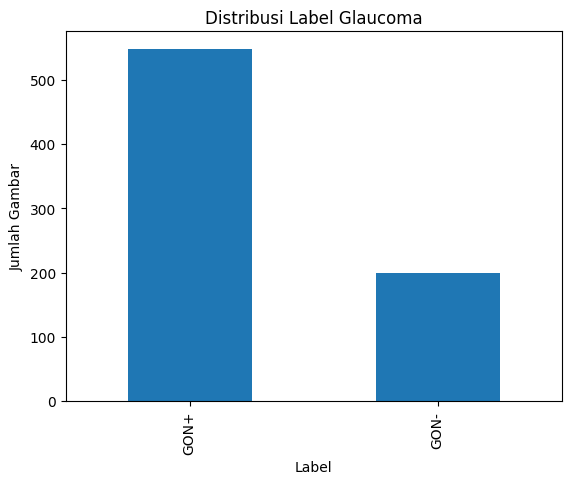

In [ ]:
hitung_label = dataset['Label'].value_counts()
hitung_label.plot(kind='bar')
plt.title("Distribusi Label Glaucoma")
plt.xlabel("Label")
plt.ylabel("Jumlah Gambar")
plt.show()

## 👤***Analisis Pasien***

### ***Analisis Gambar Per Pasien***

Total pasien unik: 288
Total gambar: 747

Distribusi jumlah foto per pasien:
Image Name
1      81
2     103
3      44
4      25
5      14
6       8
7       6
8       4
10      1
12      1
14      1
Name: count, dtype: int64


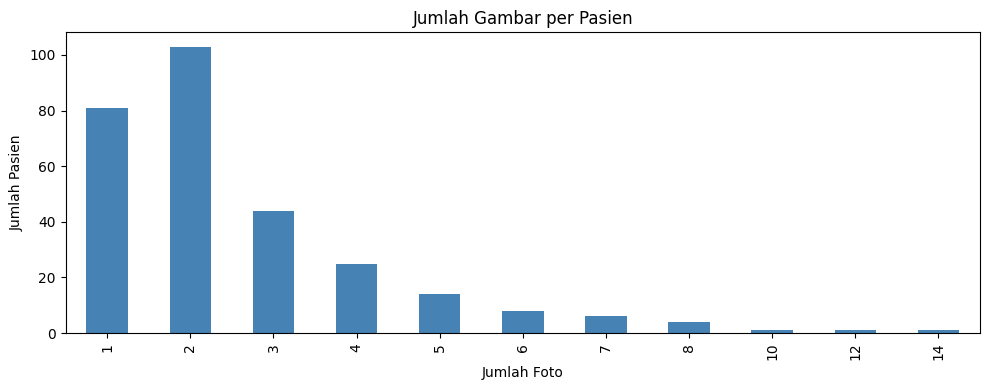

In [ ]:
imgs_per_patient = dataset.groupby("Patient")["Image Name"].count()

print(f"Total pasien unik: {dataset['Patient'].nunique()}")
print(f"Total gambar: {len(dataset)}")
print(f"\nDistribusi jumlah foto per pasien:")
print(imgs_per_patient.value_counts().sort_index())

# Visualisasi
plt.figure(figsize=(10, 4))
imgs_per_patient.value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Jumlah Gambar per Pasien")
plt.xlabel("Jumlah Foto")
plt.ylabel("Jumlah Pasien")
plt.tight_layout()
plt.show()

### ***Cek Konsistensi Label per Pasien***

In [ ]:
konsistensi = dataset.groupby("Patient")["Label"].nunique()
tidak_konsisten = konsistensi[konsistensi > 1]

print(f"Pasien dengan label konsisten (1 label): {(konsistensi == 1).sum()}")
print(f"Pasien dengan label tidak konsisten (>1 label): {len(tidak_konsisten)}")

if len(tidak_konsisten) > 0:
    print("\nDetail pasien tidak konsisten:")
    print(dataset[dataset["Patient"].isin(tidak_konsisten.index)][
        ["Patient", "Image Name", "Label"]
    ])
else:
    print("\n✅ Semua pasien hanya punya satu label — data konsisten.")

Pasien dengan label konsisten (1 label): 288
Pasien dengan label tidak konsisten (>1 label): 0

✅ Semua pasien hanya punya satu label — data konsisten.


## ⭐***Analisis Quality Score***

### ***Quality Score***

In [ ]:
print("Statistik Quality Score:")
print(dataset["Quality Score"].describe())

Statistik Quality Score:
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: Quality Score, dtype: float64


### ***Quality Score per Label***

Quality Score per Label:
       count      mean       std   min     25%   50%   75%   max
Label                                                           
GON+   548.0  5.844088  1.045786  2.04  5.2575  6.15  6.61  7.69
GON-   199.0  6.070151  0.873479  3.20  5.6300  6.22  6.65  7.68


/tmp/ipykernel_12643/579243233.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Label", y="Quality Score", data=dataset, ax=axes[0], palette="Set2")


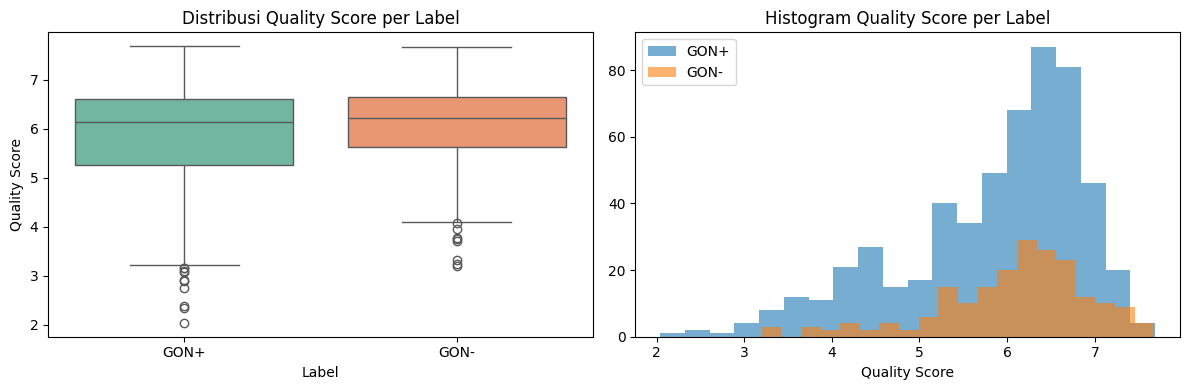

In [ ]:
print("Quality Score per Label:")
print(dataset.groupby("Label")["Quality Score"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
sns.boxplot(x="Label", y="Quality Score", data=dataset, ax=axes[0], palette="Set2")
axes[0].set_title("Distribusi Quality Score per Label")

# Histogram overlap
for label in dataset["Label"].unique():
    subset = dataset[dataset["Label"] == label]["Quality Score"]
    axes[1].hist(subset, bins=20, alpha=0.6, label=label)
axes[1].set_title("Histogram Quality Score per Label")
axes[1].set_xlabel("Quality Score")
axes[1].legend()

plt.tight_layout()
plt.show()

### ***Dampak Filtering Quality Score***

In [ ]:
print(f"{'Threshold':<12} {'Sisa Gambar':<14} {'GON+':<8} {'GON-':<8} {'Rasio GON+/GON-'}")
print("-" * 55)

for t in [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]:
    sub = dataset[dataset["Quality Score"] >= t]
    if len(sub) == 0:
        continue
    gon_plus = (sub["Label"] == "GON+").sum()
    gon_min  = (sub["Label"] == "GON-").sum()
    rasio    = gon_plus / gon_min if gon_min > 0 else float('inf')
    print(f">= {t:<9} {len(sub):<14} {gon_plus:<8} {gon_min:<8} {rasio:.2f}")

Threshold    Sisa Gambar    GON+     GON-     Rasio GON+/GON-
-------------------------------------------------------
>= 3.0       741            542      199      2.72
>= 3.5       727            531      196      2.71
>= 4.0       701            509      192      2.65
>= 4.5       652            466      186      2.51
>= 5.0       618            439      179      2.45
>= 5.5       543            385      158      2.44
>= 6.0       434            306      128      2.39


# 🖼️***Exploratory Image Analysis***

## 📐***Ukuran dan Format Gambar***

In [ ]:
path_gambar = dataset["path_gambar"][0]
gambar = Image.open(path_gambar)

print("Path_gambar: ", path_gambar)
print("Ukuran Gambar: ", gambar.size)
print("Mode Gambar: ", gambar.mode)

Path_gambar:  /content/drive/MyDrive/IDSC 2026/Dataset/Images/0_0.jpg
Ukuran Gambar:  (1918, 1918)
Mode Gambar:  RGB


In [ ]:
ukuran_gambar = []
for path in dataset["path_gambar"]:
    if os.path.exists(path):
        with Image.open(path) as img:
            ukuran_gambar.append(img.size)
    else:
        ukuran_gambar.append(None)

dataset["ukuran_gambar"] = ukuran_gambar

ukuran_valid = [s for s in ukuran_gambar if s is not None]
counter = Counter(ukuran_valid)
print(f"Jumlah ukuran unik: {len(counter)}")
print("\nDistribusi ukuran:")
for ukuran, count in counter.most_common():
    print(f"  {ukuran}: {count} gambar")

Jumlah ukuran unik: 69

Distribusi ukuran:
  (1894, 1894): 53 gambar
  (1893, 1893): 39 gambar
  (1878, 1878): 29 gambar
  (1881, 1881): 29 gambar
  (1896, 1896): 28 gambar
  (1880, 1880): 28 gambar
  (1890, 1890): 26 gambar
  (1891, 1891): 25 gambar
  (1895, 1895): 23 gambar
  (1892, 1892): 22 gambar
  (1897, 1897): 20 gambar
  (1920, 1920): 20 gambar
  (1879, 1879): 18 gambar
  (1889, 1889): 16 gambar
  (1915, 1915): 15 gambar
  (1960, 1960): 15 gambar
  (1898, 1898): 15 gambar
  (1877, 1877): 15 gambar
  (1919, 1919): 14 gambar
  (1884, 1884): 13 gambar
  (1899, 1899): 13 gambar
  (1882, 1882): 12 gambar
  (1916, 1916): 11 gambar
  (1885, 1885): 10 gambar
  (1907, 1907): 10 gambar
  (1917, 1917): 10 gambar
  (1886, 1886): 10 gambar
  (1903, 1903): 9 gambar
  (1909, 1909): 9 gambar
  (1883, 1883): 9 gambar
  (1901, 1901): 9 gambar
  (1887, 1887): 9 gambar
  (1932, 1932): 8 gambar
  (1888, 1888): 8 gambar
  (1924, 1924): 8 gambar
  (1925, 1925): 8 gambar
  (1876, 1876): 8 gambar
  (19

## 🔬***Sampel Gambar per Label QScore***

/tmp/ipykernel_12643/1763758120.py:40: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


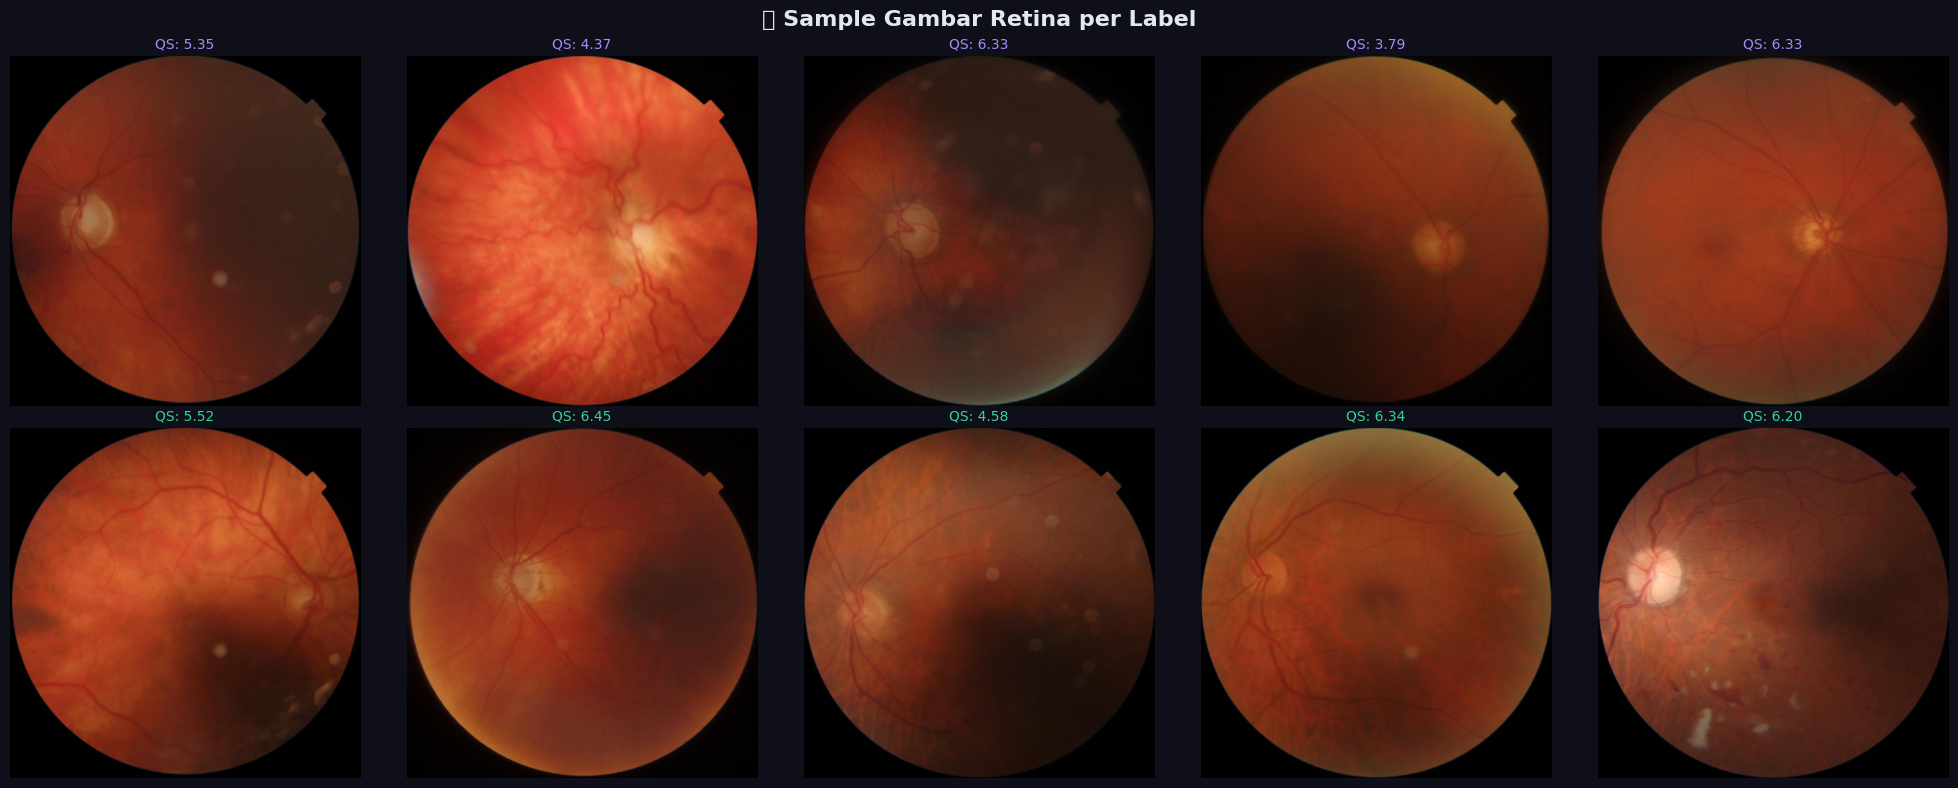

In [ ]:
#Cek Kolom yang Diperlukan
kolom_diperlukan = ["Image Name", "Label", "path_gambar"]
for kolom in kolom_diperlukan:
  if kolom not in dataset.columns:
    raise ValueError(f"Kolom {kolom} tidak ditemukan dalam dataset.")

#Cek Kolom Quality Score
kolom_quality = None
kemungkinan_quality_score = ["Quality Score", "quality score", "Quality", "quality"]

for kolom in kemungkinan_quality_score:
  if kolom in dataset.columns:
    kolom_quality= kolom
    break

# ambil 5 GON+ dan 5 GON- secara random
sample_plus  = dataset[(dataset["Label"] == "GON+") & (dataset["file_exist"])].sample(5, random_state=42)
sample_minus = dataset[(dataset["Label"] == "GON-") & (dataset["file_exist"])].sample(5, random_state=42)
samples = pd.concat([sample_plus, sample_minus])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor("#0F0F1A")
fig.suptitle("🔬 Sample Gambar Retina per Label", fontsize=16, color="#E2E8F0", fontweight="bold")

for i, (_, row) in enumerate(sample_plus.iterrows()):
    axes[0, i].imshow(Image.open(row["path_gambar"]))
    axes[0, i].set_title(f'QS: {row["Quality Score"]:.2f}', color="#A78BFA", fontsize=10)
    axes[0, i].axis("off")
    axes[0, i].set_facecolor("#1A1A2E")

for i, (_, row) in enumerate(sample_minus.iterrows()):
    axes[1, i].imshow(Image.open(row["path_gambar"]))
    axes[1, i].set_title(f'QS: {row["Quality Score"]:.2f}', color="#34D399", fontsize=10)
    axes[1, i].axis("off")
    axes[1, i].set_facecolor("#1A1A2E")

axes[0, 0].set_ylabel("GON+", color="#A78BFA", fontsize=13, fontweight="bold", rotation=90, labelpad=10)
axes[1, 0].set_ylabel("GON-", color="#34D399", fontsize=13, fontweight="bold", rotation=90, labelpad=10)

plt.tight_layout()
plt.show()

## 📉 ***Sample QS Rendah vs Tinggi***

/tmp/ipykernel_12643/2658400120.py:31: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12643/2658400120.py:31: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12643/2658400120.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12643/2658400120.py:31: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/p

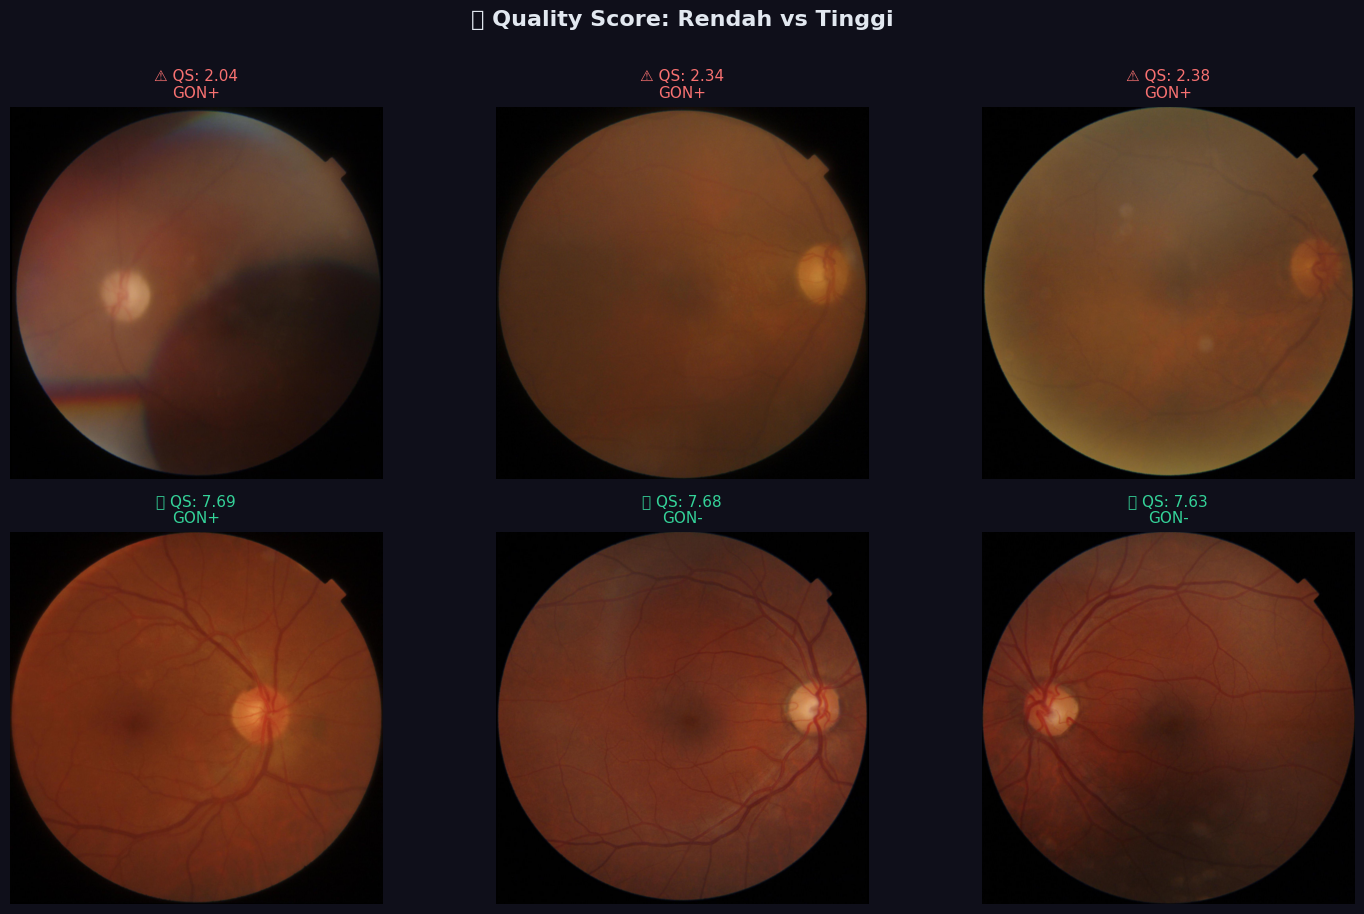

In [ ]:
# Ambil 3 gambar QS terendah dan 3 tertinggi
low_qs  = dataset[dataset["file_exist"]].nsmallest(3, "Quality Score")
high_qs = dataset[dataset["file_exist"]].nlargest(3, "Quality Score")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor("#0F0F1A")
fig.suptitle("📉 Quality Score: Rendah vs Tinggi",
             fontsize=16, color="#E2E8F0", fontweight="bold", y=1.01)

for i, (_, row) in enumerate(low_qs.iterrows()):
    img = Image.open(row["path_gambar"])
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'⚠️ QS: {row["Quality Score"]:.2f}\n{row["Label"]}',
                         color="#F87171", fontsize=11)
    axes[0, i].axis("off")
    axes[0, i].set_facecolor("#1A1A2E")

for i, (_, row) in enumerate(high_qs.iterrows()):
    img = Image.open(row["path_gambar"])
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'✅ QS: {row["Quality Score"]:.2f}\n{row["Label"]}',
                         color="#34D399", fontsize=11)
    axes[1, i].axis("off")
    axes[1, i].set_facecolor("#1A1A2E")

# Label baris
for ax, label in zip([axes[0,0], axes[1,0]], ["🔴  LOW QUALITY", "🟢  HIGH QUALITY"]):
    ax.set_ylabel(label, color="#E2E8F0", fontsize=12, fontweight="bold",
                  rotation=90, labelpad=10)

plt.tight_layout()
plt.show()